In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [127]:
def exp_func(lmbd, p):
    return -1 / lmbd * np.log(p)

def generate_request_time_exp(lmbd, work_time):
    T_server = [0]
    while True:
        new_t = T_server[-1] + exp_func(lmbd, np.random.rand())
        if new_t > work_time:
            break
        T_server.append(new_t)
    T_server.pop(0)
    return np.asarray(T_server)

def generate_process_time_exp(lmbd, n):
    return exp_func(lmbd, np.random.rand(n))

def simulate(Ts, Tz):
    last_time = 0
    processed_signals = 0
    for i in range(len(Ts)):
        if last_time <= Ts[i]:
            last_time = Ts[i] + Tz[i]
            processed_signals += 1
    return processed_signals

def simulate_with_acc(Ts, Tz):
    last_time = 0
    pre_last_time = 0
    processed_signals = 0
    work_time = 0
    all_t_rej = []
    for i in range(len(Ts)):
        if last_time <= Ts[i]:
            all_t_rej.append(0)
            pre_last_time = last_time
            last_time = Ts[i] + Tz[i]
            processed_signals += 1
            work_time += Tz[i]
        elif pre_last_time <= Ts[i]:
            all_t_rej.append(last_time - Ts[i])
            pre_last_time = last_time
            last_time += Tz[i]
            processed_signals += 1
            work_time += Tz[i]
        else:
            all_t_rej.append(0)
             
    return processed_signals, work_time, all_t_rej

In [32]:
lmbd = 0.32
mu = 0.4
T = 1000

In [115]:
T_req = generate_request_time_exp(lmbd, T)
T_processing = generate_process_time_exp(mu, len(T_req))

processed_requests, work_t, all_t_rej = simulate_with_acc(T_req, T_processing)

print("============Симуляция============")
print(f"Число обработанных программ: {processed_requests}")
print(f"Число отказов: {len(T_req) - processed_requests}")
print(f"Общее число программ: {len(T_req)}")
print(f"Относительная пропускная способность: {processed_requests / len(T_req)}")
print(f"Время работы процессора: {work_t}")
print(f"Время простоя процессора: {T - work_t}")
print(f"Вероятность загрузки процессора: {work_t / T}")
print(f"Вероятность простоя процессора: {1 - (work_t / T)}")
print(f"Вероятность отказа в обслуживании: {np.sum(all_t_rej) / T}")
print(f"Абсолютная пропускная способность: {processed_requests / T}")
print(f"Коэфф. загрузки каналов: {work_t / T}")
print(f"Вероятность нахождения заявки в накопителе: {np.sum(all_t_rej) / T}")
print(f"Среднее число заявок в очереди: {np.sum(all_t_rej) / T}")
print(f"Среднее время ожидания в очереди: {np.mean(all_t_rej)}")

============Симуляция============
Число обработанных программ: 250
Число отказов: 88
Общее число программ: 338
Относительная пропускная способность: 0.7396449704142012
Время работы процессора: 590.8339806568391
Время простоя процессора: 409.1660193431609
Вероятность загрузки процессора: 0.5908339806568391
Вероятность простоя процессора: 0.4091660193431609
Вероятность отказа в обслуживании: 0.25993489498910566
Абсолютная пропускная способность: 0.25
Коэфф. загрузки каналов: 0.5908339806568391
Вероятность нахождения заявки в накопителе: 0.25993489498910566
Среднее число заявок в очереди: 0.25993489498910566
Среднее время ожидания в очереди: 0.7690381508553422


In [67]:
p = lmbd / mu
p_free = 1 / (1 + p + p**2)
p_rej = p**2 * p_free
Q = 1 - p_rej
A = Q * lmbd
k = A / mu
p_in_acc = p**2 * p_free
L = p**2 * p_free
mean_t_acc = L / lmbd
print("============Теория============")
print(f"Вероятность простоя процессора: {p_free}")
print(f"Вероятность отказа в обслуживании: {p_rej}")
print(f"Относительная пропускная способность: {Q}")
print(f"Абсолютная пропускная способность: {A}")
print(f"Коэфф. загрузки каналов: {k}")
print(f"Вероятность нахождения заявки в накопителе: {p_in_acc}")
print(f"Среднее число заявок в очереди: {L}")
print(f"Среднее время ожидания в очереди: {mean_t_acc}")

============Теория============
Вероятность простоя процессора: 0.40983606557377056
Вероятность отказа в обслуживании: 0.26229508196721313
Относительная пропускная способность: 0.7377049180327868
Абсолютная пропускная способность: 0.23606557377049178
Коэфф. загрузки каналов: 0.5901639344262294
Вероятность нахождения заявки в накопителе: 0.26229508196721313
Среднее число заявок в очереди: 0.26229508196721313
Среднее время ожидания в очереди: 0.819672131147541


In [125]:
mu4 = 1
ros4 = np.linspace(0.1, 1, 1000)[:-1]
T = 1000

Z = []
Z1 = []
for ro in ros4:
    lmbd4 = ro * mu4
    T_req = generate_request_time_exp(lmbd4, T)
    T_processing = generate_process_time_exp(mu4, len(T_req))

    processed_requests, work_t, all_t_rej = simulate_with_acc(T_req, T_processing)
    Z.append(processed_requests / len(T_req))
    Z1.append(work_t / T)

Pobr = (1 + ros4) / (1 + ros4 + ros4**2)
Ps = ros4 * (1 - ros4**2) / (1 - ros4**3)
    

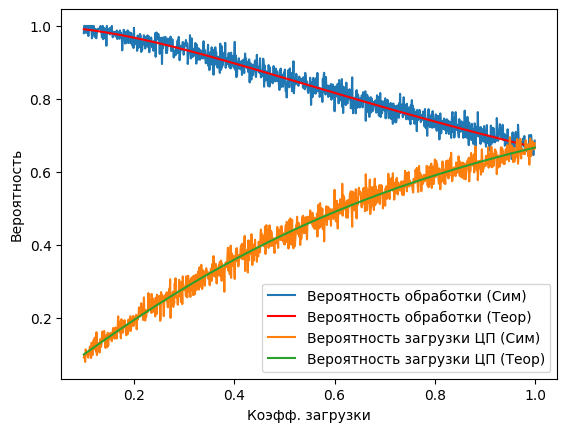

In [126]:
plt.plot(ros4, Z, label='Вероятность обработки (Сим)')
plt.plot(ros4, Pobr, color='red', label='Вероятность обработки (Теор)')
plt.plot(ros4, Z1, label='Вероятность загрузки ЦП (Сим)')
plt.plot(ros4, Ps, label='Вероятность загрузки ЦП (Теор)')
plt.xlabel("Коэфф. загрузки")
plt.ylabel("Вероятность")
plt.legend()
plt.show()

In [ ]:
mu4 = 1
ros4 = np.linspace(0.1, 1, 1000)[:-1]
T = 1000

Q_acc = []
Q_clear = []
for ro in ros4:
    lmbd4 = ro * mu4
    T_req = generate_request_time_exp(lmbd4, T)
    T_processing = generate_process_time_exp(mu4, len(T_req))

    processed_requests, work_t, all_t_rej = simulate_with_acc(T_req, T_processing)
    Q_acc.append(processed_requests / len(T_req))

    processed_requests_clear = simulate(T_req, T_processing)
    Q_clear.append(processed_requests_clear / len(T_req))


Q_acc_theor = (1 - ros4**2) / (1 - ros4**3)
Q_clear_theor = 1 / (1 + ros4)
    

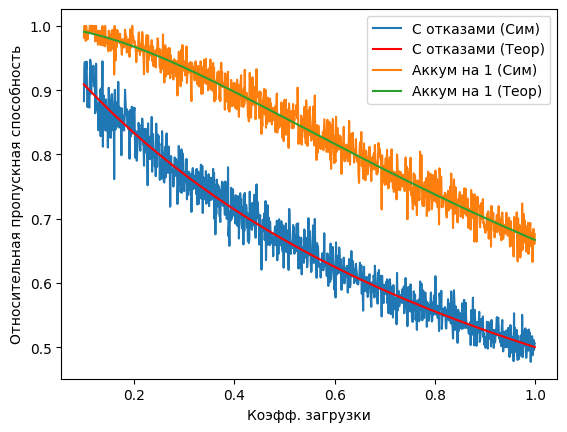

In [133]:
plt.plot(ros4, Q_clear, label='С отказами (Сим)')
plt.plot(ros4, Q_clear_theor, color='red', label='С отказами (Теор)')
plt.plot(ros4, Q_acc, label='Аккум на 1 (Сим)')
plt.plot(ros4, Q_acc_theor, label='Аккум на 1 (Теор)')
plt.xlabel("Коэфф. загрузки")
plt.ylabel("Относительная пропускная способность")
plt.legend()
plt.show()

In [148]:
mu4 = 1
ros4 = np.linspace(0.1, 1, 1000)[:-1]
T = 1000

c1 = 1
qf = 0.15
qr = 0.01

E_acc = []
E_clear = []
# Pf_acc = []
# Pf_clear = []
for ro in ros4:
    lmbd4 = ro * mu4
    T_req = generate_request_time_exp(lmbd4, T)
    T_processing = generate_process_time_exp(mu4, len(T_req))

    processed_requests, work_t, all_t_rej = simulate_with_acc(T_req, T_processing)
    E_acc.append(processed_requests * c1 - (len(T_req) - processed_requests) * qf - np.mean(all_t_rej) * qr)

    processed_requests_clear = simulate(T_req, T_processing)
    E_clear.append(processed_requests_clear * c1 - (len(T_req) - processed_requests) * qf)

lmbds = ros4 * mu4

tr = ros4**2 / (1 + ros4 + ros4**2) / lmbds


Pf_acc = ros4**2 * (1 / (1 + ros4 + ros4**2))
Pf_clear = ros4 * (1 / (1 + ros4))

E_acc_theor = ((1 - ros4**2) / (1 - ros4**3)) * 0.5 * c1 - qf * (1 - (1 - ros4**2) / (1 - ros4**3)) * 0.5 - qr * ros4**2 / ((1 + ros4 + ros4**2) * 0.5)
E_clear_theor = (1 - ros4 / (1 + ros4)) * 0.5 * c1 - qf * (ros4 / (1 + ros4)) * 0.5
    

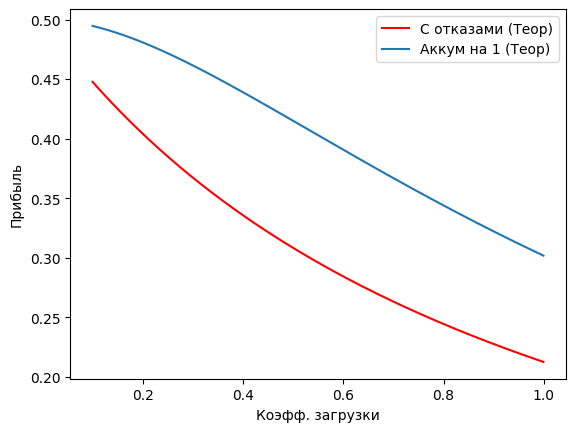

In [ ]:
# plt.plot(ros4, E_clear, label='С отказами (Сим)')
plt.plot(ros4, E_clear_theor, color='red', label='С отказами (Теор)')
# plt.plot(ros4, E_acc, label='Аккум на 1 (Сим)')
plt.plot(ros4, E_acc_theor, label='Накопитель на 1 (Теор)')
plt.xlabel("Коэфф. загрузки")
plt.ylabel("Прибыль")
plt.legend()
plt.show()